In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
from sklearn.manifold import TSNE

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/heart.csv')

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
# 1. Preprocessing Data
print("="*50)
print("1. PREPROCESSING DATA")
print("="*50)

1. PREPROCESSING DATA


In [ ]:
# Tampilkan ringkasan data
print("\nRingkasan Dataset:")
print(f"Jumlah Fitur: {data.shape[1]}")
print(f"Jumlah data: {da.shape[0]}")
print(f"Jumlah Kelas: {df['HeartDisease'].nunique()} (0 = Sehat, 1 = Gagal Jantung)")
print("\nInformasi Dataset:")
print(df.info())


Ringkasan Dataset:
Jumlah Fitur: 12
Jumlah data: 918
Jumlah Kelas: 2 (0 = Sehat, 1 = Gagal Jantung)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


In [ ]:
print("\nStatistik Deskriptif:")
df.describe()


Statistik Deskriptif:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
# Periksa missing values
print("\nCek Missing Values:")
print(df.isnull().sum())


Cek Missing Values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [ ]:
# Encode fitur kategorikal
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
print("\n info tipe data setelah encode:")
df.info()
print("\n detail isi setelah encode:")
df.head()


 info tipe data setelah encode:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    int64  
 2   ChestPainType   918 non-null    int64  
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    int64  
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    int64  
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    int64  
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 86.2 KB

 detail isi setelah encode:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [ ]:
# 1.3 Scaling Data
print("="*50)
print("1.3 SCALING DATA")
print("="*50)

1.3 SCALING DATA


In [ ]:
from sklearn.preprocessing import StandardScaler

# Pisahkan fitur dan target
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

<Figure size 1500x1000 with 0 Axes>

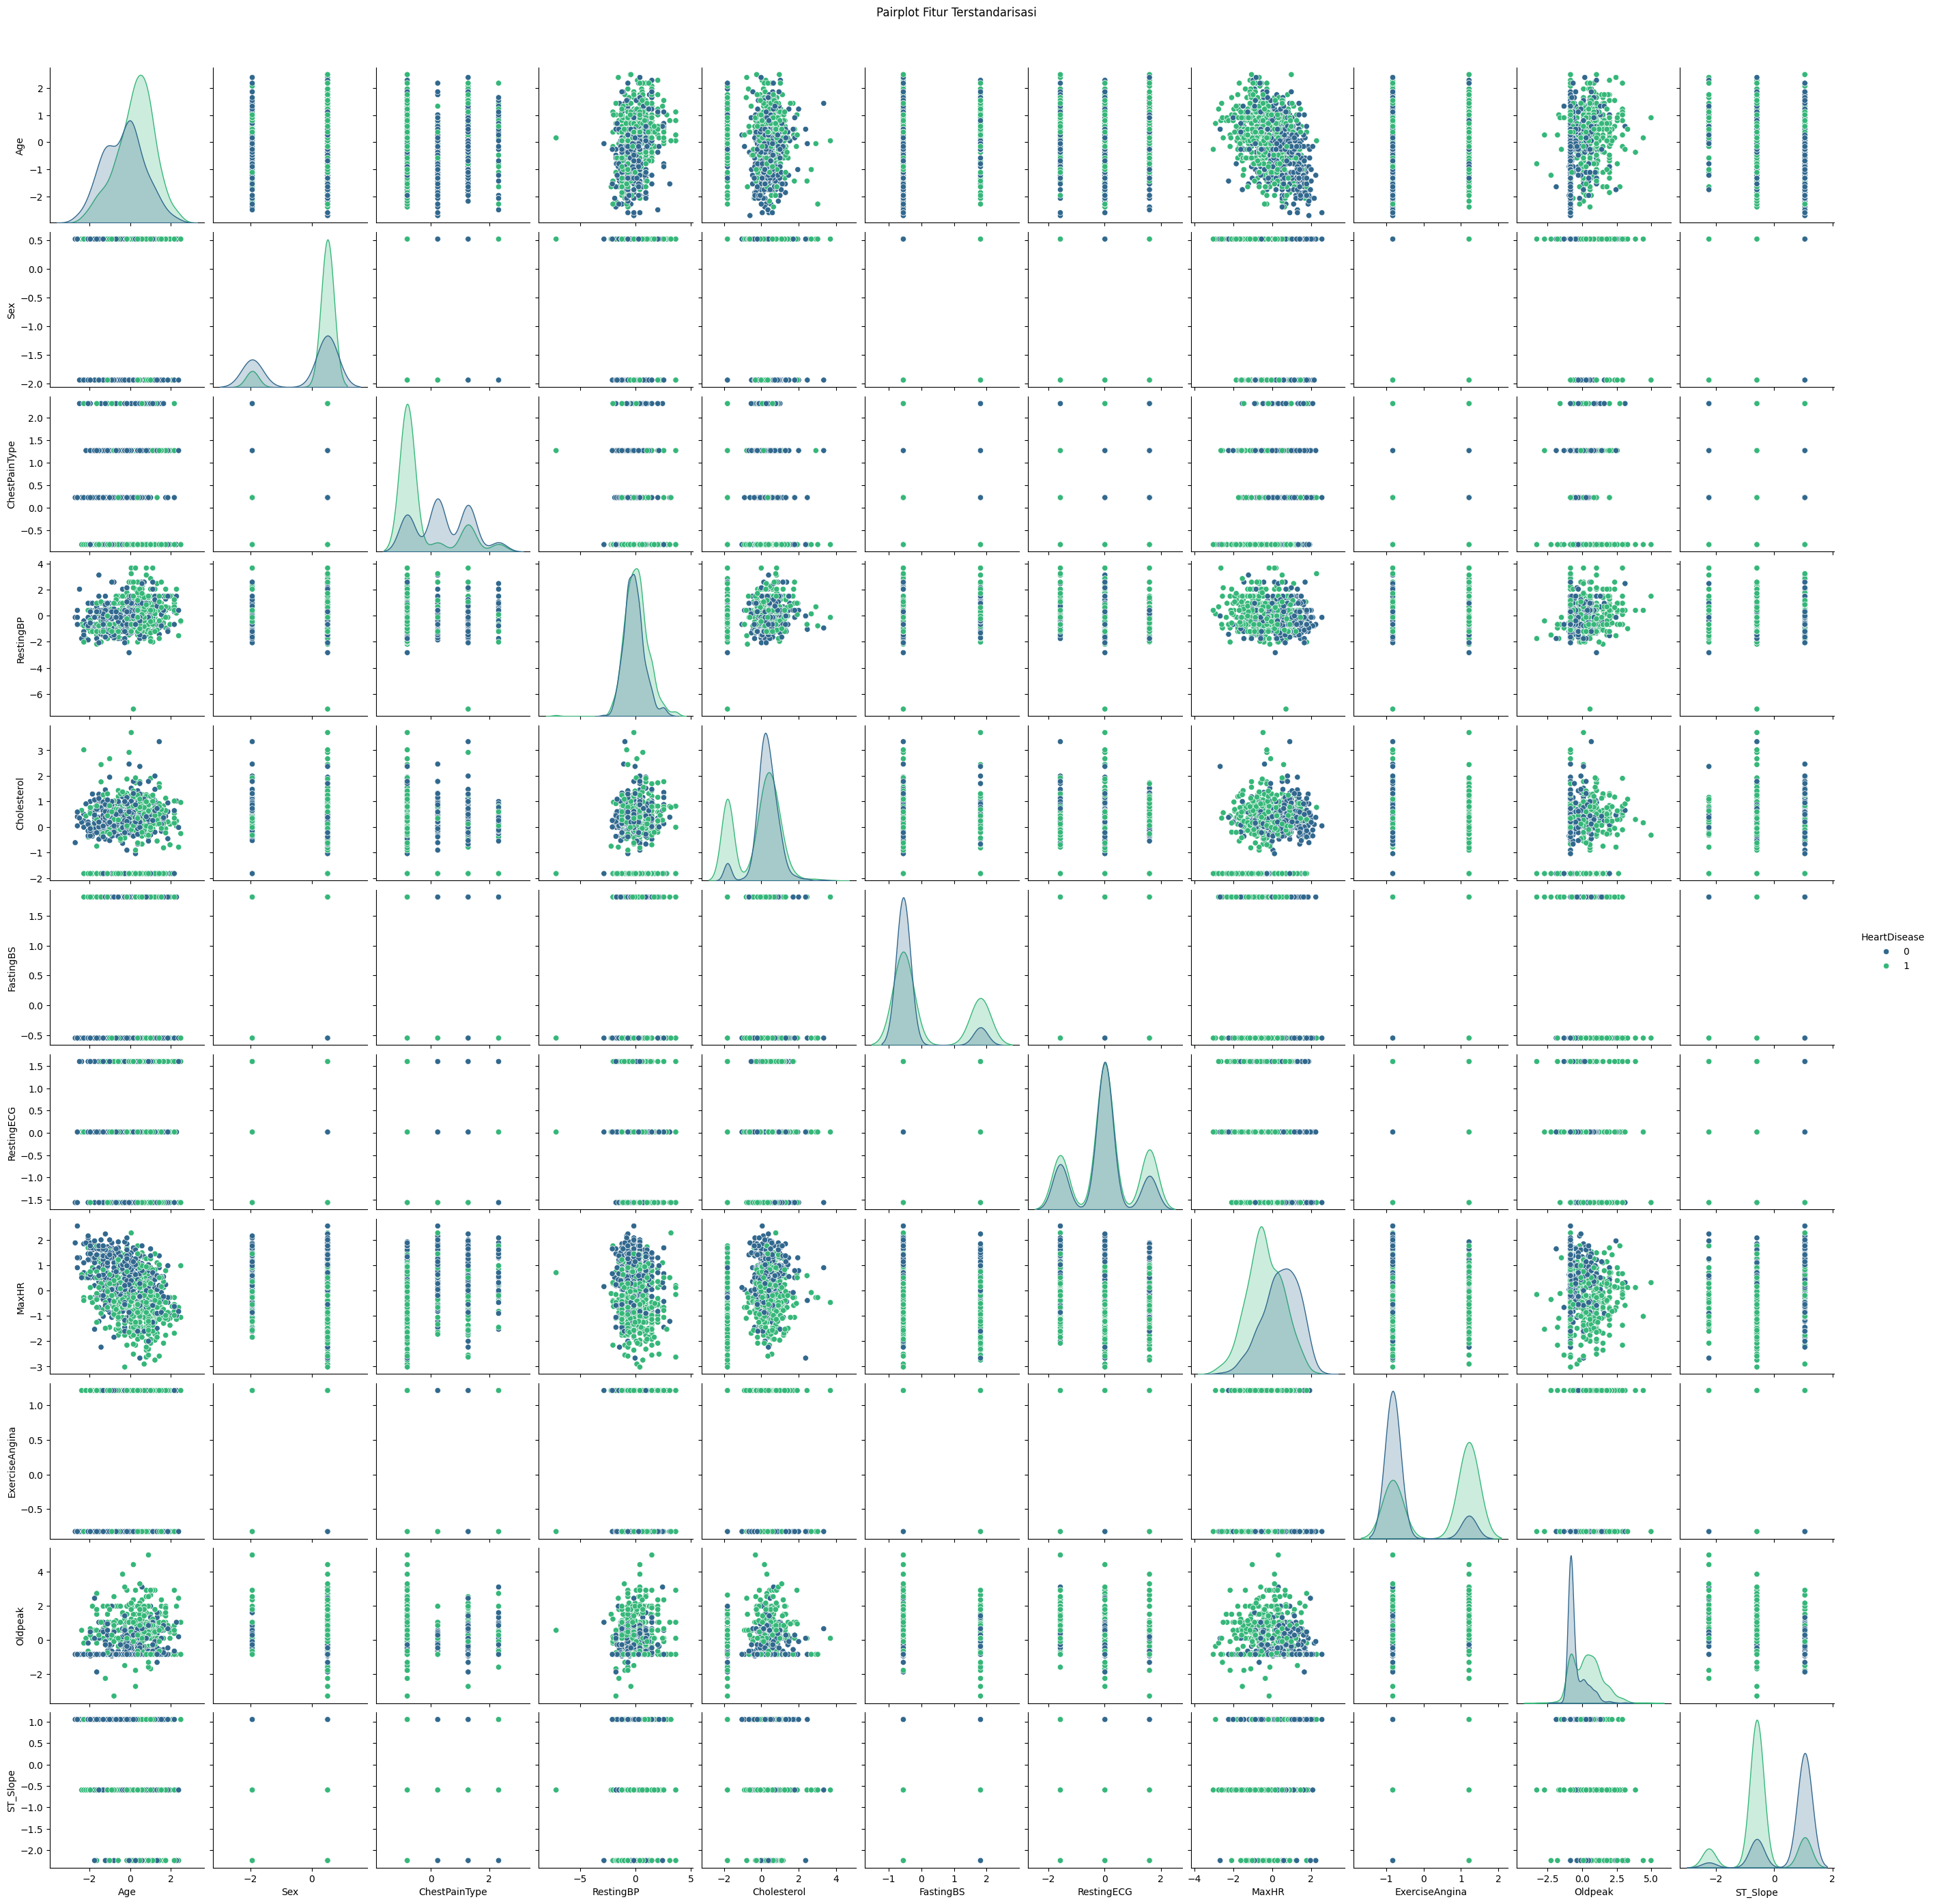

In [ ]:
# Visualisasi sebaran data
plt.figure(figsize=(15, 10))
sns.pairplot(pd.concat([X_scaled, y], axis=1), hue='HeartDisease', palette='viridis')
plt.suptitle('Pairplot Fitur Terstandarisasi', y=1.02)
plt.show()

In [ ]:
# 2. Feature Engineering
print("\n" + "="*50)
print("2. FEATURE ENGINEERING")
print("="*50)


2. FEATURE ENGINEERING


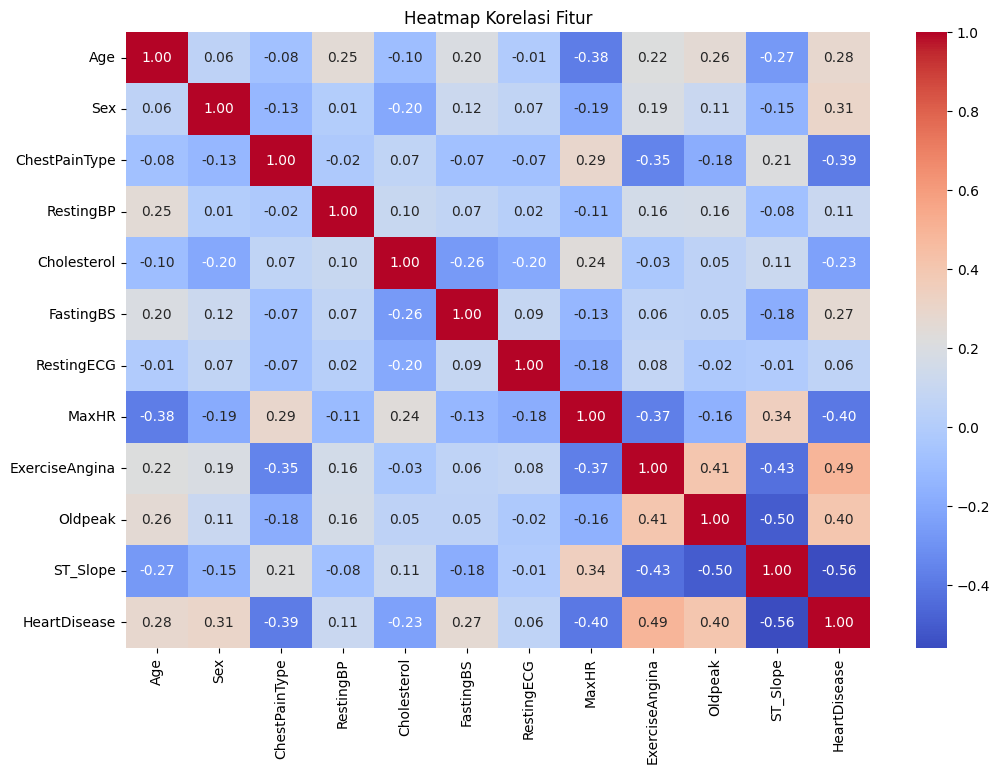

In [ ]:
# Analisis korelasi
plt.figure(figsize=(12, 8))
corr_matrix = pd.concat([X_scaled, y], axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Fitur')
plt.show()

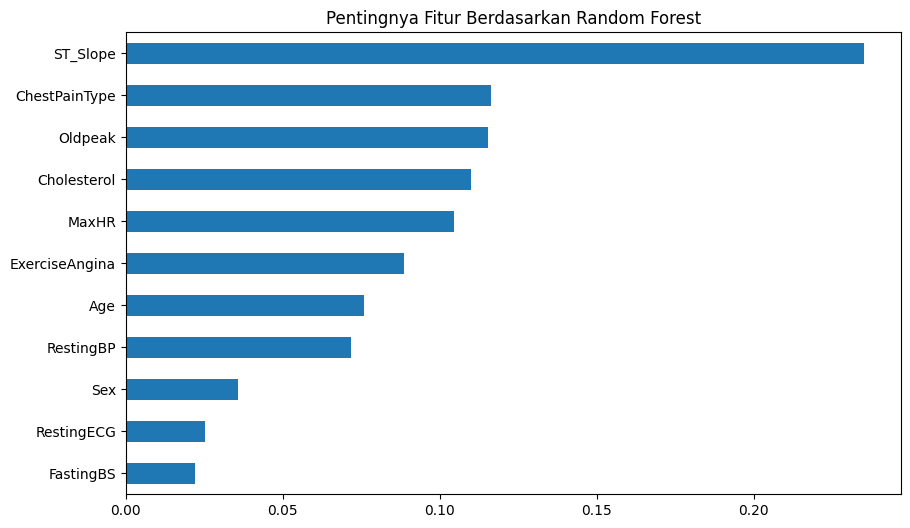

In [ ]:
# Seleksi fitur dengan Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)
feature_importances = pd.Series(rf.feature_importances_, index=X_scaled.columns)
plt.figure(figsize=(10, 6))
feature_importances.sort_values().plot(kind='barh')
plt.title('Pentingnya Fitur Berdasarkan Random Forest')
plt.show()

In [ ]:
# Seleksi 5 fitur terbaik
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import mutual_info_classif

selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X_scaled, y)
selected_features = X_scaled.columns[selector.get_support()]
print("\n5 Fitur Terpilih:")
print(selected_features)


5 Fitur Terpilih:
Index(['ChestPainType', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope'], dtype='object')


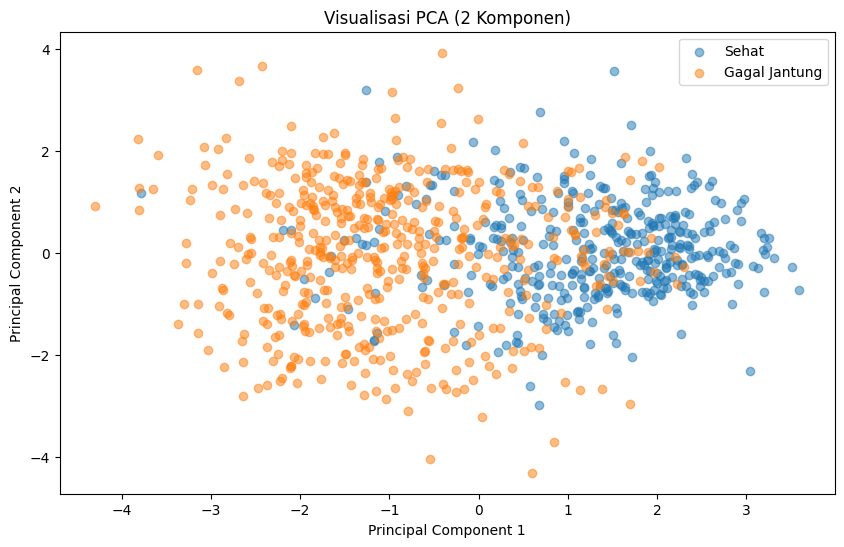

In [ ]:
# Reduksi dimensi dengan PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], alpha=0.5, label='Sehat')
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], alpha=0.5, label='Gagal Jantung')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Visualisasi PCA (2 Komponen)')
plt.legend()
plt.show()

In [ ]:
# Gunakan fitur terpilih untuk modeling
X_selected = X_scaled[selected_features]

In [ ]:
# 3. Klasifikasi
print("\n" + "="*50)
print("3. KLASIFIKASI")
print("="*50)


3. KLASIFIKASI


In [ ]:
# Bagi data menjadi train dan test (80:20)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Pisahkan data menjadi train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Inisialisasi model
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)

# Latih model
knn.fit(X_train, y_train)
svm.fit(X_train, y_train)

# Prediksi
knn_pred = knn.predict(X_test)
svm_pred = svm.predict(X_test)

In [ ]:
# Evaluasi
def evaluate_model(model_name, y_true, y_pred):
    print(f"\nEvaluasi {model_name}:")
    print(f"Akurasi: {accuracy_score(y_true, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

evaluate_model("k-NN", y_test, knn_pred)
evaluate_model("SVM", y_test, svm_pred)


Evaluasi k-NN:
Akurasi: 0.7989

Confusion Matrix:
[[63 19]
 [18 84]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.77      0.77        82
           1       0.82      0.82      0.82       102

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.80      0.80      0.80       184


Evaluasi SVM:
Akurasi: 0.8207

Confusion Matrix:
[[62 20]
 [13 89]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        82
           1       0.82      0.87      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.81      0.82       184
weighted avg       0.82      0.82      0.82       184



In [ ]:
# 4. Visualisasi Decision Boundary
print("\n" + "="*50)
print("4. VISUALISASI DECISION BOUNDARY")
print("="*50)


4. VISUALISASI DECISION BOUNDARY


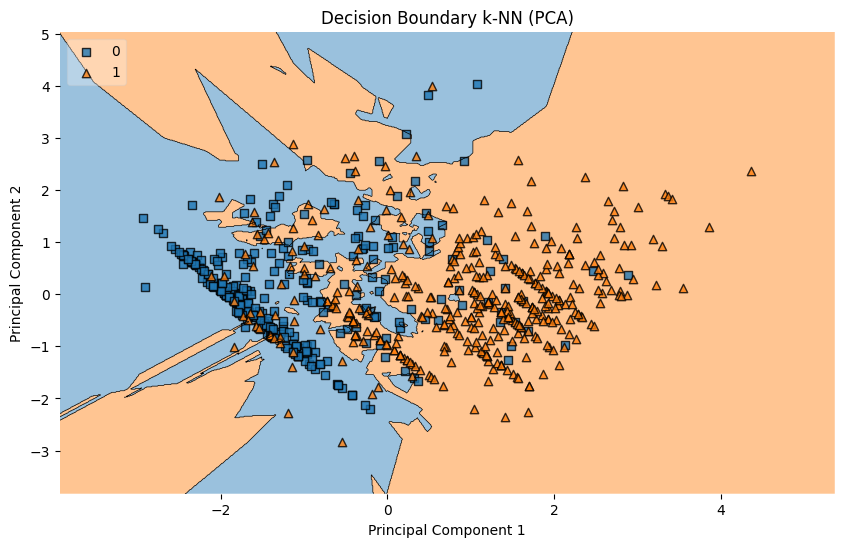

In [ ]:
# Gunakan PCA untuk visualisasi 2D
from mlxtend.plotting import plot_decision_regions

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

# Latih ulang model dengan data PCA
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)

plt.figure(figsize=(10, 6))
plot_decision_regions(X_train_pca, y_train.values, clf=knn_pca, legend=2)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Decision Boundary k-NN (PCA)')
plt.show()

In [ ]:
# 5. Analisis Hasil
print("\n" + "="*50)
print("5. ANALISIS HASIL")
print("="*50)

print("\nKekuatan dan Kelemahan Metode:")
print("k-NN:")
print("- Kekuatan: Mudah diimplementasi, intuitif, tidak perlu asumsi distribusi data")
print("- Kelemahan: Sensitif terhadap fitur tidak relevan, mahal komputasi untuk dataset besar")

print("\nSVM:")
print("- Kekuatan: Efektif di ruang dimensi tinggi, tahan overfitting dengan parameter yang tepat")
print("- Kelemahan: Sulit diinterpretasi, perlu tuning parameter, lambat untuk dataset besar")

print("\nPengaruh Fitur Terhadap Performa:")
print("Fitur terpilih berdasarkan analisis:")
print("1. Oldpeak - Depresi ST (Pengaruh kuat: perubahan EKG saat aktivitas)")
print("2. Sex - Jenis kelamin (Pria lebih berisiko)")
print("3. ExerciseAngina - Angina saat olahraga (Indikator kuat masalah jantung)")
print("4. Age - Usia (Risiko meningkat seiring usia)")
print("5. ST_Slope - Kemiringan segmen ST (Indikator iskemia jantung)")

print("\nFitur seperti Cholesterol dan RestingBP memiliki pengaruh lebih rendah")
print("karena variasi besar dan kemungkinan noise dalam data medis.")


5. ANALISIS HASIL

Kekuatan dan Kelemahan Metode:
k-NN:
- Kekuatan: Mudah diimplementasi, intuitif, tidak perlu asumsi distribusi data
- Kelemahan: Sensitif terhadap fitur tidak relevan, mahal komputasi untuk dataset besar

SVM:
- Kekuatan: Efektif di ruang dimensi tinggi, tahan overfitting dengan parameter yang tepat
- Kelemahan: Sulit diinterpretasi, perlu tuning parameter, lambat untuk dataset besar

Pengaruh Fitur Terhadap Performa:
Fitur terpilih berdasarkan analisis:
1. Oldpeak - Depresi ST (Pengaruh kuat: perubahan EKG saat aktivitas)
2. Sex - Jenis kelamin (Pria lebih berisiko)
3. ExerciseAngina - Angina saat olahraga (Indikator kuat masalah jantung)
4. Age - Usia (Risiko meningkat seiring usia)
5. ST_Slope - Kemiringan segmen ST (Indikator iskemia jantung)

Fitur seperti Cholesterol dan RestingBP memiliki pengaruh lebih rendah
karena variasi besar dan kemungkinan noise dalam data medis.
